## Non Linear Activation function (ReLU)

Non Linear activation functions are used in the scenario when we are working on a complex Non linear data. The real world data that we work on is more Non Linear in nature.

ReLU which is also known as Rectified Linear Unit is used to build a more sophisticated model that learns of data's complexities better.

# <span style="color:blue">0. Importing PyTorch Libraries</span>

As usual let us import the essential libraries first.

In [3]:
#Importing the libraries

import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils

# <span style="color:blue">1. Gathering the input data </span>

Let us gather the input data for distances and times

In [4]:
# Taking the input data

# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)


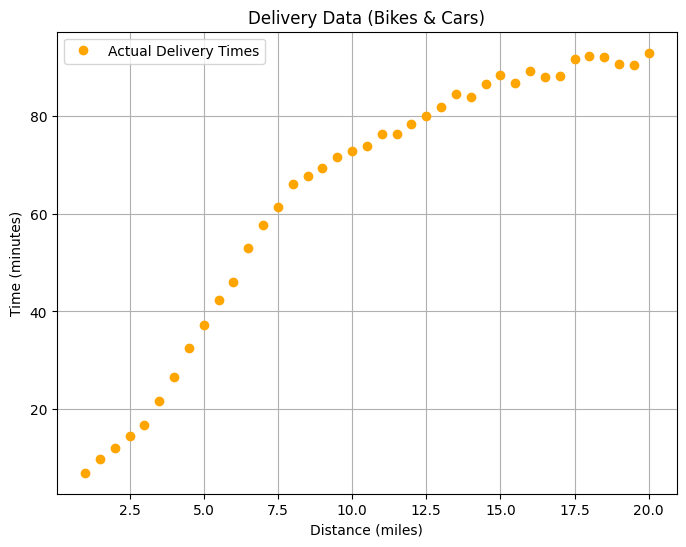

In [5]:
helper_utils.plot_data(distances, times)

# <span style="color:blue">2. Normalising the input data </span>

Normalising is the act of readjusting the scale of data so that the training process is more stable and effective.

To normalise any data first compute the individual 'mean' & 'standard deviation'.

Once done normalised i/p would be computed using the formula:
    
    
x_norm = (x - x_mean)/x_std


where      
      
      x -> i/p 

      x_mean -> mean of i/p computed using x.mean()
    
      x_std  -> standard deviation of i/p computed using x.std()
        
        

In [6]:
# Normalising the scale --> makes training process more stable

distances_mean = distances.mean()
distances_std = distances.std()


times_mean = times.mean()
times_std = times.std()


distances_norm = (distances - distances_mean)/distances_std
times_norm = (times - times_mean)/times_std

print(f"Normalised distance:{distances_norm}\n\nNormalised time:{times_norm}")

print(f"Normalised distance:{distances_norm.shape}\n\nNormalised time:{times_norm.shape}")

Normalised distance:tensor([[-1.6664],
        [-1.5787],
        [-1.4910],
        [-1.4033],
        [-1.3156],
        [-1.2279],
        [-1.1402],
        [-1.0525],
        [-0.9648],
        [-0.8771],
        [-0.7894],
        [-0.7016],
        [-0.6139],
        [-0.5262],
        [-0.4385],
        [-0.3508],
        [-0.2631],
        [-0.1754],
        [-0.0877],
        [ 0.0000],
        [ 0.0877],
        [ 0.1754],
        [ 0.2631],
        [ 0.3508],
        [ 0.4385],
        [ 0.5262],
        [ 0.6139],
        [ 0.7016],
        [ 0.7894],
        [ 0.8771],
        [ 0.9648],
        [ 1.0525],
        [ 1.1402],
        [ 1.2279],
        [ 1.3156],
        [ 1.4033],
        [ 1.4910],
        [ 1.5787],
        [ 1.6664]])

Normalised time:tensor([[-2.0442],
        [-1.9472],
        [-1.8599],
        [-1.7722],
        [-1.6931],
        [-1.5166],
        [-1.3441],
        [-1.1311],
        [-0.9636],
        [-0.7775],
        [-0.6433],
        [-0.

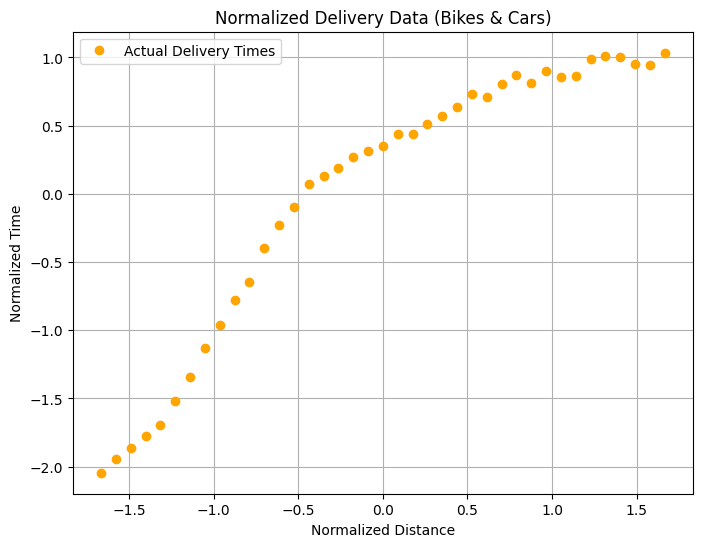

In [17]:
# Plotting the normalised input
helper_utils.plot_data(distances_norm, times_norm, normalize = True)

# <span style="color:blue">3. Defining the model </span>

Once normalised, we then define the model as a Sequential Linear 1 i/p 3 o/p inpiy layer, ReLU activation layer in the middle
followed by Linear 3 i/p  1 o/p layer at the end.

In [7]:
# Defining the model

model = nn.Sequential(nn.Linear(1,3), nn.ReLU(), nn.Linear(3,1))


# <span style="color:blue">4. Defining Loss & Optimizer </span>

Loss function as ususal is computed using MSELoss() from nn library.

Whereas Optimizer is computed using SGD on model paremeters (w,b) supplemented by a learning rate. We use optim libary to do 
so.

In [8]:
# Defining the loss parameter & SGD

loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

# <span style="color:blue">5. Training the model </span>

Once model, loss and optim is defined, then we jump onto training the model.
The epoch used here is around 3000.


Again some key concepts one needs to know:

    1. optimizer.zero_grad() is used to reset the optimizer gradients.
    
    2. model(i/p) does the prediction on i/p
    
    3. We then estimate the diff b/w Predicted i/p & o/p. This is what we call as Loss.
    
    4. We then back propagate/ bacward pass to reduce the Loss

    5. optimizer.step() just simply updates the model parameter.
    

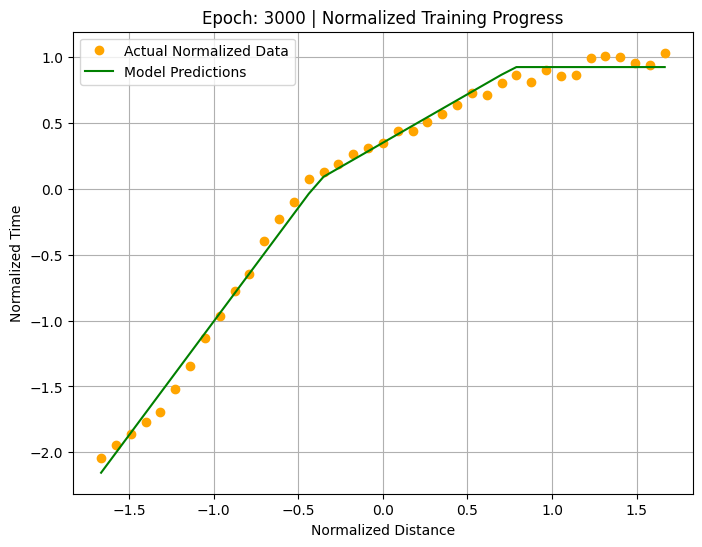


Training Complete.

Final Loss: 0.004786610137671232


In [9]:
# Training the model

for epoch in range(3000):
    #Reset the optim
    optimizer.zero_grad()
    
    #Placing the input
    output = model(distances_norm)
    
    
    # Estimating the loss
    
    loss = loss_function(output, times_norm)
    
    
    # Back propagation
    loss.backward()
    
    
    #Update the model parameters
    optimizer.step()
    
    
    if (epoch + 1)%50  == 0:
        helper_utils.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm
        )
        

print("\nTraining Complete.")
print(f"\nFinal Loss: {loss.item()}")    

# <span style="color:blue">6. Prediction on test data</span>

Let us now predict on a scalar model of distance using the trained model to see how well is it performing.

In [10]:
# Prediction on a scalar distance

"""Let us predict the model for a scalar distance, where distance = 5.1 """

distance_to_predict = 5.1

# Don't calculate any gradient, faster compute--> we use torch.no_grad()
with torch.no_grad():
    
    
    # Converting the Scalar i/p into a [[1]]  shape tensor
    user_input = torch.tensor([[distance_to_predict]], dtype = torch.float32)
    
    # Normalising the i/p (sclaing it) using training mean & std
    user_input_norm = (user_input - distances_mean)/distances_std
    print(f"User input: {user_input.item()}; User input norm: {user_input_norm.item()}")
    
    
    # initialising the model
    predicted_user_input_norm = model(user_input_norm)
    predicted_time_actual = (predicted_user_input_norm * times_std) + times_mean
    
    
    print(f"Predicted time for a {distance_to_predict} delivery: {predicted_time_actual.item():.2f}")

User input: 5.099999904632568; User input norm: -0.9472226500511169
Predicted time for a 5.1 delivery: 38.52
